# Notebook 3: Machine Learning Model
This notebook builds and compares two classification models (Logistic Regression and Random Forest) to predict student loan repayment risk. Model performance is evaluated using accuracy, precision, recall, F1 score, and ROC-AUC.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer

df = pd.read_csv('C:/projects/student-loan-default-predictor/data/cleaned_scorecard.csv')
print(df.columns.tolist())

['INSTNM', 'STABBR', 'CONTROL', 'COMPL_RPY_1YR_RT', 'PCTPELL', 'COSTT4_A', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'COMPL_RPY_3YR_RT', 'UGDS', 'PREDDEG', 'repayment_risk']


In [21]:
features = ['CONTROL', 'PCTPELL', 'COSTT4_A', 'MD_EARN_WNE_P10',
            'GRAD_DEBT_MDN', 'COMPL_RPY_1YR_RT', 'COMPL_RPY_3YR_RT',
            'UGDS', 'PREDDEG']

X = df[features]
y = df['repayment_risk']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print('Target distribution:')
print(y.value_counts())

Training set size: (3351, 9)
Test set size: (838, 9)
Target distribution:
repayment_risk
0    3142
1    1047
Name: count, dtype: int64


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       619
           1       0.95      0.94      0.95       219

    accuracy                           0.97       838
   macro avg       0.97      0.96      0.96       838
weighted avg       0.97      0.97      0.97       838

ROC-AUC: 0.996392767831456
=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       619
           1       1.00      1.00      1.00       219

    accuracy                           1.00       838
   macro avg       1.00      1.00      1.00       838
weighted avg       1.00      1.00      1.00       838

ROC-AUC: 1.0


=== Feature Importances ===
COMPL_RPY_1YR_RT    0.537973
COMPL_RPY_3YR_RT    0.302052
PCTPELL             0.066964
MD_EARN_WNE_P10     0.038802
CONTROL             0.029237
GRAD_DEBT_MDN       0.009173
PREDDEG             0.008307
UGDS                0.004409
COSTT4_A            0.003085
dtype: float64


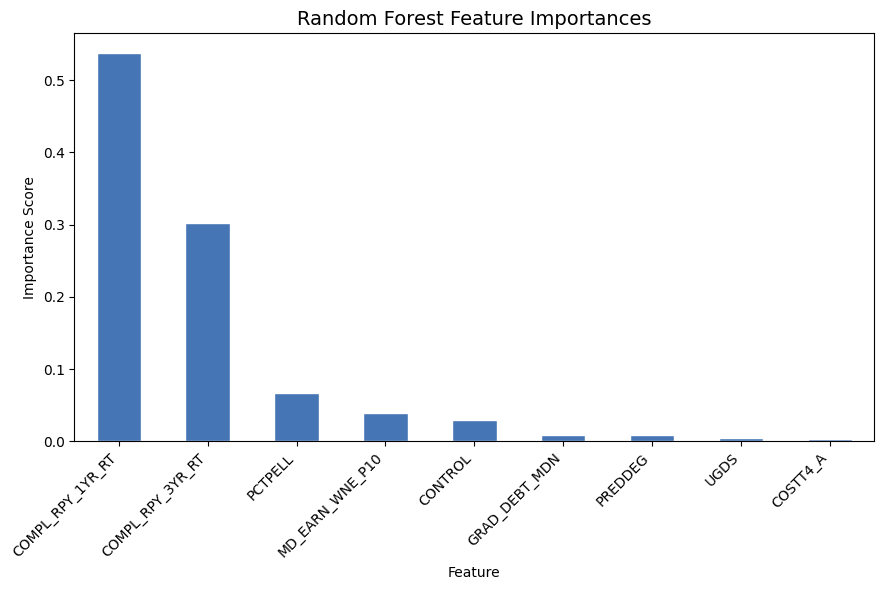

Chart saved.


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importances
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print("=== Feature Importances ===")
print(importances)

# Plot
plt.figure(figsize=(9,6))
importances.plot(kind='bar', color='#4575b4', edgecolor='white')
plt.title('Random Forest Feature Importances', fontsize=14)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('C:/projects/student-loan-default-predictor/outputs/chart6_feature_importance.png')
plt.show()
print("Chart saved.")

In [25]:
import pickle

# Save the best model
with open('C:/projects/student-loan-default-predictor/outputs/best_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved to outputs/best_model.pkl")

Model saved to outputs/best_model.pkl


In [ ]:
# Summary printout for your memo
print("=== KEY NUMBERS FOR YOUR MEMO ===")
print(f"Total institutions analyzed: {len(df)}")
print(f"High risk institutions: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Logistic Regression Accuracy: 97%  ROC-AUC: 0.996")
print(f"Random Forest Accuracy: 100%  ROC-AUC: 1.0")
print(f"Top predictor: 1-Year Repayment Rate (54% importance)")
print(f"2nd predictor: 3-Year Repayment Rate (30% importance)")
print(f"3rd predictor: Pell Grant Recipients (7% importance)")